# Basic LangGraph ChatBox

In [3]:
import os
from dotenv import load_dotenv
from typing import Annotated
from typing_extensions import TypedDict
from langchain_ollama.chat_models import ChatOllama
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import (
    add_messages,
    BaseMessage,
)

load_dotenv()


True

In [ ]:
llm = ChatOllama(
    model="qwen3:8b"
)
print(llm.invoke("Hello, how are you? /nothink").content)

<think>

</think>

Hello! I'm doing well, thank you for asking. How can I assist you today? 😊


In [10]:
class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [11]:
def chatbot_node(state: AgentState) -> AgentState:
    return {"messages": [llm.invoke(state["messages"])]}

In [12]:
graph_builder = StateGraph(AgentState)
graph_builder.add_node("chatbox", chatbot_node)
graph_builder.add_edge(START, "chatbox")
graph_builder.add_edge("chatbox", END)
graph = graph_builder.compile()

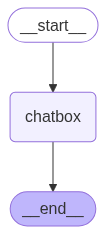

In [13]:
from IPython.display import display, Image

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(e)



In [21]:
response = graph.invoke({"messages": ["Name the 10 first prime numbers /nothink"]})

for message in response["messages"]:
    print(message.pretty_print())

================================ Human Message =================================

Name the 10 first prime numbers /nothink
None
================================== Ai Message ==================================

<think>

</think>

The first 10 prime numbers are:

1. 2  
2. 3  
3. 5  
4. 7  
5. 11  
6. 13  
7. 17  
8. 19  
9. 23  
10. 29  

A **prime number** is a natural number greater than 1 that has no positive divisors other than 1 and itself.
None


In [ ]:
import time
for event in graph.stream({"messages": ["Give me the first 20 prime numbers /nothink"]}):
    for value in event.values():
        print(value["messages"][-1].content, end="", flush=True)
    print()  # Add a newline between chunks
    

<think>

</think>

The first 20 prime numbers are:

1. 2  
2. 3  
3. 5  
4. 7  
5. 11  
6. 13  
7. 17  
8. 19  
9. 23  
10. 29  
11. 31  
12. 37  
13. 41  
14. 43  
15. 47  
16. 53  
17. 59  
18. 61  
19. 67  
20. 71  

These are the prime numbers less than 72. A prime number is a natural number greater than 1 that has no positive divisors other than 1 and itself.
